# Vision Transformer
Use a pretrained ViT and fine tune it on our custom dataset of only a few classes of dogs.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
DATA_DIR = "dataset"        # Root folder containing train/ and test/ subfolders
IMG_SIZE = 224              # ViT standard input size (224x224 pixels)
BATCH_SIZE = 32             # Number of images per training batch
EPOCHS = 10                 # Number of times the model sees the entire training data
LR = 3e-5                   # Learning rate (how fast the model learns)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
OUTPUT_DIR = "./out"        # Where we save the best trained model
os.makedirs(OUTPUT_DIR, exist_ok=True)  # Ensure the folder exists

In [3]:
# -----------------------------
# Data transforms / augmentations
# -----------------------------
# Pretrained ViTs expect normalized images (ImageNet stats), so we normalize inputs
# We also apply basic augmentation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Resize images to 224x224
    transforms.RandomHorizontalFlip(),        # Randomly flip images horizontally
    transforms.RandomRotation(15),            # Randomly rotate images ±15 degrees
    transforms.ToTensor(),                    # Convert images to PyTorch tensors (0-1)
    transforms.Normalize([0.485, 0.456, 0.406],  # Subtract mean (ImageNet)
                         [0.229, 0.224, 0.225])  # Divide by std (ImageNet)
])

# For validation/test, we don't apply augmentation, only resize and normalize
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
# ImageFolder expects a folder structure like:
# dataset/train/class1, dataset/train/class2, etc.
full_train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transforms)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=test_transforms)

# Split training data into train + validation (90/10 split)
val_size = int(0.1 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Wrap datasets in DataLoader for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)



In [ ]:
# -----------------------------
# Load pretrained ViT model; define optimizer and loss
# -----------------------------
num_classes = len(full_train_dataset.classes)  # How many categories we have
model = timm.create_model('vit_base_patch16_224', pretrained=True)  # Pretrained on ImageNet

# Replace the classification head to match our dataset
model.head = nn.Linear(model.head.in_features, num_classes)

model = model.to(DEVICE)  # Move model to GPU if available

criterion = nn.CrossEntropyLoss()  # Standard loss for classification
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)  # Modern optimizer
scaler = torch.cuda.amp.GradScaler()  # Enables mixed precision training for speed & memory efficiency


/tmp/ipykernel_71464/3971174148.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Enables mixed precision training for speed & memory efficiency


In [ ]:
best_val_acc = 0  # Track best validation accuracy to save the best model

for epoch in range(EPOCHS):
    # -----------------------------
    # Training
    # -----------------------------
    model.train()  # Set model to training mode
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()  # Reset gradients
        # Mixed precision: speeds up training and uses less memory
        with torch.cuda.amp.autocast():
            outputs = model(images)         # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
        scaler.scale(loss).backward()  # Backpropagation
        scaler.step(optimizer)         # Update weights
        scaler.update()                # Update scaler for mixed precision
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # -----------------------------
    # Validation
    # -----------------------------
    model.eval()  # Switch to evaluation mode (disables dropout, etc.)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    # Save the model if validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model.pth"))

Epoch 1/10:   0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_71464/3694698480.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 | Train Loss: 0.3754 | Val Acc: 1.0000 | Val F1: 1.0000


Epoch 2/10:   0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_71464/3694698480.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

/tmp/ipykernel_71464/3694698480.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 9 | Train Loss: 0.0000 | Val Acc: 1.0000 | Val F1: 1.0000


Epoch 10/10:   0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_71464/3694698480.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10 | Train Loss: 0.0000 | Val Acc: 1.0000 | Val F1: 1.0000


Test Accuracy: 1.0000, Test F1: 1.0000


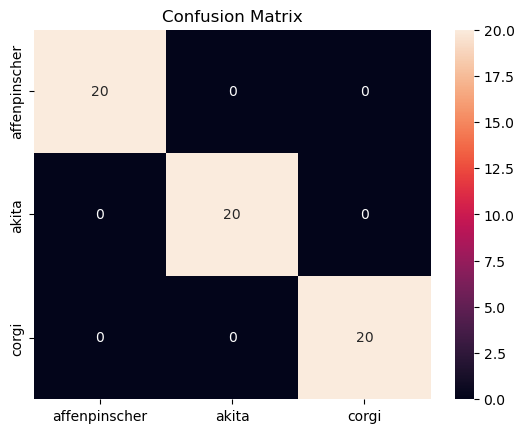

In [7]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_model.pth")))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"Test Accuracy: {test_acc:.4f}, Test F1: {test_f1:.4f}")

# -----------------------------
# Confusion matrix for detailed performance
# -----------------------------
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=full_train_dataset.classes, yticklabels=full_train_dataset.classes)
plt.title("Confusion Matrix")
plt.show()